In [16]:
#initial import of relevant packages for graphing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#https://stackoverflow.com/questions/32085531/importing-a-csv-file-into-python-to-make-scatterplots-and-histograms

In [17]:
#initial read and print of motifs_dataframe
motifs_df = pd.read_csv("../rosetta_motifs/rmsd_total_best_10000.csv")
motifs_df

,system,rmsd,placement_pdb
0,aa2ar,3.759347,aa2ar_ResPos_159_ResID_PHE_Trio33_+_motif_3QO7...
1,abl1,0.086350,abl1_ResPos_83_ResID_THR_Trio24_+_motif_7CD9_F...
2,ace,0.368597,ace_ResPos_293_ResID_SER_Trio17_+_motif_7Q26_8...
3,aces,0.111413,aces_ResPos_359_ResID_HIS_Trio68_+_motif_7AIS_...
4,ada17,0.939694,ada17_ResPos_123_ResID_THR_Trio46_+_motif_3IEB...
...,...,...,...
86,thrb,0.202464,thrb_ResPos_111_ResID_LEU_Trio52_+_motif_6AUE_...
87,tryb1,0.349357,tryb1_ResPos_87_ResID_GLN_Trio5_+_motif_7VHY_6...
88,tysy,0.450841,tysy_ResPos_79_ResID_ILE_Trio48_+_motif_2ZF4_P...
89,urok,0.214195,urok_ResPos_178_ResID_ASP_Trio58_+_motif_6EO6_...


In [18]:
#initial read and print of Schrodinger Glide dataframe
dock_df = pd.read_csv("../dock6/dock6_best_rmsds.csv")
dock_df

,system,rmsd
0,def,1.091496
1,nram,5.959094
2,fa10,0.180092
3,fak1,0.278123
4,aofb,0.417968
...,...,...
97,aldr,0.527157
98,inha,1.124074
99,pur2,0.610745
100,pgh2,0.233567


In [19]:
#remove any nan
dock_df = dock_df[dock_df['rmsd'].isna() == False]
dock_df

,system,rmsd
0,def,1.091496
1,nram,5.959094
2,fa10,0.180092
3,fak1,0.278123
4,aofb,0.417968
...,...,...
97,aldr,0.527157
98,inha,1.124074
99,pur2,0.610745
100,pgh2,0.233567


In [20]:
#Inner join of motifs and dock dataframes for plotting purposes; followed with test print
merged_df = pd.merge(motifs_df, dock_df, on='system', how='inner')
merged_df

,system,rmsd_x,placement_pdb,rmsd_y
0,aa2ar,3.759347,aa2ar_ResPos_159_ResID_PHE_Trio33_+_motif_3QO7...,0.602898
1,abl1,0.086350,abl1_ResPos_83_ResID_THR_Trio24_+_motif_7CD9_F...,0.202259
2,ace,0.368597,ace_ResPos_293_ResID_SER_Trio17_+_motif_7Q26_8...,0.875376
3,aces,0.111413,aces_ResPos_359_ResID_HIS_Trio68_+_motif_7AIS_...,0.136633
4,ada17,0.939694,ada17_ResPos_123_ResID_THR_Trio46_+_motif_3IEB...,0.509063
...,...,...,...,...
86,thrb,0.202464,thrb_ResPos_111_ResID_LEU_Trio52_+_motif_6AUE_...,0.254926
87,tryb1,0.349357,tryb1_ResPos_87_ResID_GLN_Trio5_+_motif_7VHY_6...,0.228896
88,tysy,0.450841,tysy_ResPos_79_ResID_ILE_Trio48_+_motif_2ZF4_P...,1.454266
89,urok,0.214195,urok_ResPos_178_ResID_ASP_Trio58_+_motif_6EO6_...,0.271452


In [21]:
#drop non-needed columns from merged dataframe
merged_df = merged_df.drop(columns=['placement_pdb'])
#rename columns for rmsd from motifs and autodock
merged_df.columns = ['system', 'rmsd_motifs', 'rmsd_dock']
#test_print
merged_df

,system,rmsd_motifs,rmsd_dock
0,aa2ar,3.759347,0.602898
1,abl1,0.086350,0.202259
2,ace,0.368597,0.875376
3,aces,0.111413,0.136633
4,ada17,0.939694,0.509063
...,...,...,...
86,thrb,0.202464,0.254926
87,tryb1,0.349357,0.228896
88,tysy,0.450841,1.454266
89,urok,0.214195,0.271452


In [22]:
type(merged_df['rmsd_dock'][0])
type(merged_df['rmsd_motifs'][0])
print(merged_df['rmsd_dock'])

0     0.602898
1     0.202259
2     0.875376
3     0.136633
4     0.509063
        ...   
86    0.254926
87    0.228896
88    1.454266
89    0.271452
90    0.507777
Name: rmsd_dock, Length: 91, dtype: float64


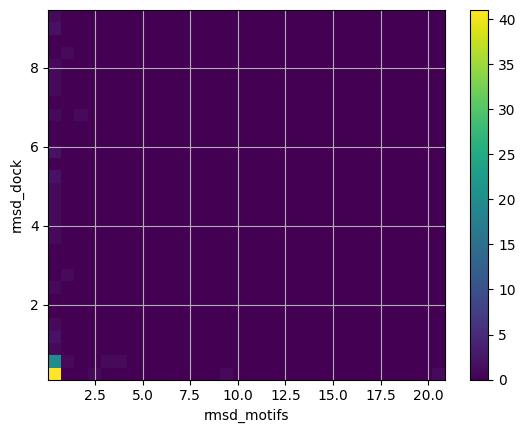

In [23]:
#Create heatmap of rmsds per system (n=85) between AutoDock and Rosetta Motifs

#copy out rmsd columns of motifs and autodock
x = merged_df['rmsd_motifs']
y = merged_df['rmsd_dock']

#create a 2d histogram of the rmsd columns with 30 bins in each dimension
heatmap, xedges, yedges = np.histogram2d(x, y, bins=(30, 30))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

#set plot labels
plt.xlabel('rmsd_motifs')
plt.ylabel('rmsd_dock')

#create 2d heatmap using viridis color scale
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='viridis', aspect='auto')

#add color bar
plt.colorbar()

#add grid
plt.grid(True)

#show plot
plt.show()

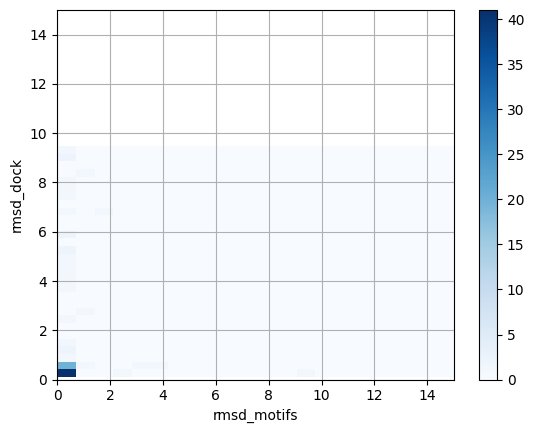

In [24]:
#Create heatmap of rmsds per system (n=85) between AutoDock and Rosetta Motifs
#Expanding x and y max to 10
#Using Blues color scale to allow for zeros to be white

x = merged_df['rmsd_motifs']
y = merged_df['rmsd_dock']

heatmap, xedges, yedges = np.histogram2d(x, y, bins=(30, 30))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.xlabel('rmsd_motifs')
plt.ylabel('rmsd_dock')

plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='Blues', aspect='auto')

plt.colorbar()

plt.grid(True)
plt.xlim(0,15)
plt.ylim(0,15)
plt.show()

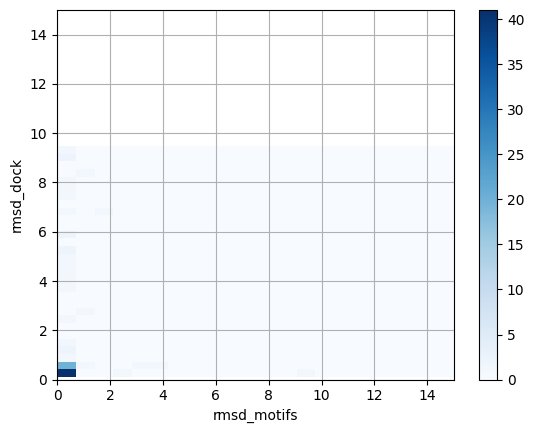

In [25]:
#Create heatmap of rmsds per system (n=85) between AutoDock and Rosetta Motifs
#Expanding x and y max to 10
#Using Blues color scale to allow for zeros to be white

x = merged_df['rmsd_motifs']
y = merged_df['rmsd_dock']

heatmap, xedges, yedges = np.histogram2d(x, y, bins=(30, 30))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.xlabel('rmsd_motifs')
plt.ylabel('rmsd_dock')

plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='Blues', aspect='auto')

plt.colorbar()

plt.grid(True)
plt.xlim(0,15)
plt.ylim(0,15)
plt.show()

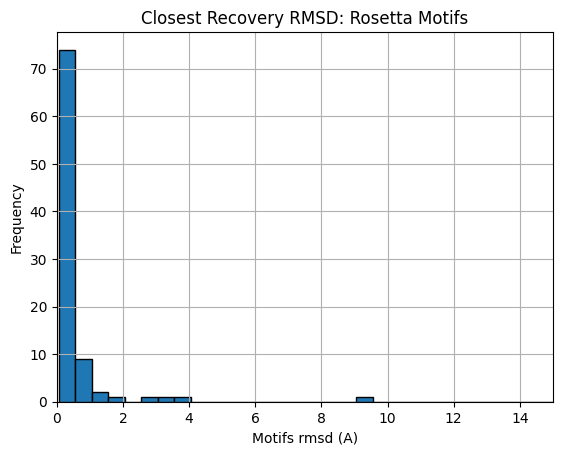

In [26]:
#create heatmap of Motifs closest recovery RMSDs

#extract motifs rmsds
x = merged_df['rmsd_motifs']
#set labels and title
plt.xlabel('Motifs rmsd (A)')
plt.ylabel('Frequency')
plt.title('Closest Recovery RMSD: Rosetta Motifs')
#create 30 bin 1D hsitogram
plt.xlim(0,15)
bin_edges = np.arange(min(x), max(x) + 0.5, 0.5)
#plt.hist(x, bins=bin_edges, color='blue')
plt.hist(x, bins=bin_edges, edgecolor='black')
#set grid
plt.grid(True)
#show plot
plt.show()

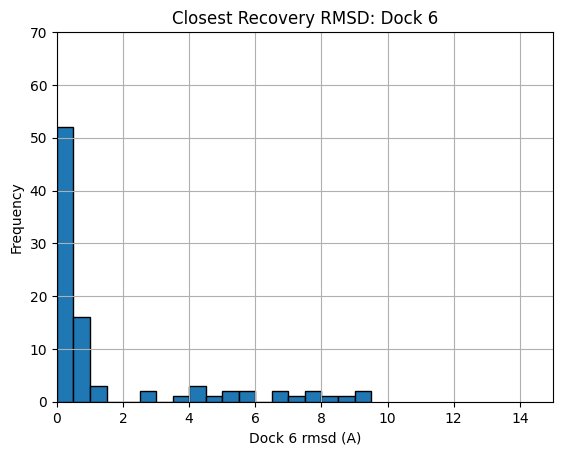

In [27]:
#create heatmap of Schrodinger closest recovery RMSDs

x = merged_df['rmsd_dock']
plt.xlabel('Dock 6 rmsd (A)')
plt.ylabel('Frequency')
plt.title('Closest Recovery RMSD: Dock 6')
plt.xlim(0,15)
plt.ylim(0,70)
bin_edges = np.arange(0, max(x) + 0.5, 0.5)
#plt.hist(x, bins=bin_edges, color='blue')
plt.hist(x, bins=bin_edges, edgecolor='black')
plt.grid(True)
plt.savefig("sf1b_dock6_histogram.svg", format="svg")
plt.show()

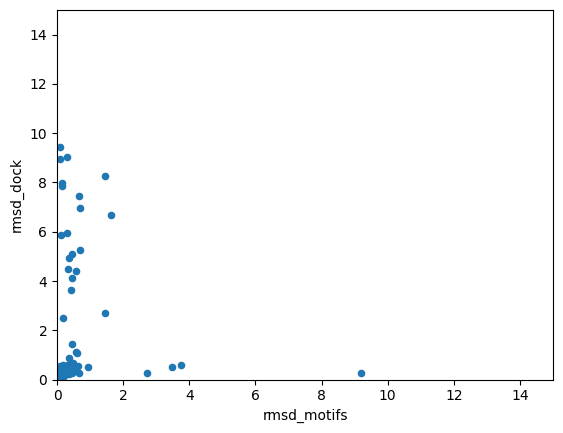

In [28]:
#make a scatterplot in the place of the heatmap
merged_df.plot(kind='scatter',x='rmsd_motifs',y='rmsd_dock')
plt.xlim(0,15)
plt.ylim(0,15)
plt.show()

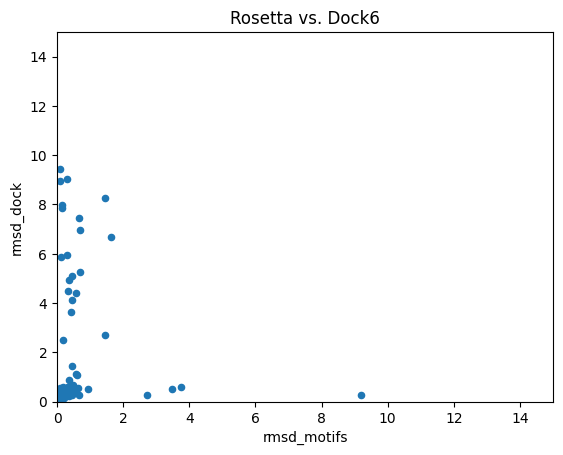

In [29]:
#make a scatterplot in the place of the heatmap
merged_df.plot(kind='scatter',x='rmsd_motifs',y='rmsd_dock')
plt.xlim(0,15)
plt.ylim(0,15)
plt.title("Rosetta vs. Dock6")
plt.savefig("sf1b_dock6_vs_motifs_plot.svg", format="svg")
plt.show()

In [30]:
#get a list of the dock placements that are really far away from native (>20 angstrom rmsd)
#remove any nan
dock_df_awful_rmsd = dock_df[dock_df['rmsd'] > 20]
dock_df_awful_rmsd

,system,rmsd
